In [ ]:
def check_no_prediction_overlaps_bbox(gsam_metadata, artifact_type, predictions, 
                                    confidence_threshold=0.3, overlap_threshold=0.1):
    """
    Check if NO predictions with target class name overlap with the target bbox above a minimal threshold.
    This is the opposite of simple_check_prediction_covers_bbox.
    
    Args:
        gsam_metadata: The loaded GSAM metadata dictionary
        artifact_type: The specific artifact type key
        predictions: The predictions dictionary from GSAM detector
        confidence_threshold: Minimum confidence score (default: 0.3)
        overlap_threshold: Minimal overlap ratio to consider as overlap (default: 0.1 = 10%)
    
    Returns:
        bool: True if NO predictions overlap with target bbox above threshold, False if any do overlap
    """
    
    # Get target class name and find its index in vocab
    target_class_name = gsam_metadata['artifacts'][artifact_type]['class_name']
    vocab = gsam_metadata['vocab']
    target_class_idx = vocab.index(target_class_name)
    
    # Get target bbox
    target_bbox = gsam_metadata['artifacts'][artifact_type]['patch_data']['target_bbox']
    target_xmin, target_ymin, target_xmax, target_ymax = target_bbox
    
    # Check predictions
    for i, class_idx in enumerate(predictions['pred_classes']):
        if (class_idx.item() == target_class_idx and 
            predictions['scores'][i].item() >= confidence_threshold):
            
            # Get the prediction mask
            pred_mask = predictions['pred_masks'][i]
            
            # Create target bbox mask
            mask_height, mask_width = pred_mask.shape
            target_mask = torch.zeros((mask_height, mask_width), dtype=torch.bool)
            
            # Convert bbox coordinates to integer pixel coordinates
            bbox_xmin = max(0, int(target_xmin))
            bbox_ymin = max(0, int(target_ymin))
            bbox_xmax = min(mask_width, int(target_xmax))
            bbox_ymax = min(mask_height, int(target_ymax))
            
            # Fill target bbox area in mask
            target_mask[bbox_ymin:bbox_ymax, bbox_xmin:bbox_xmax] = True
            
            # Calculate intersection and overlap ratio
            intersection_area = torch.sum(pred_mask & target_mask).item()
            target_bbox_area = torch.sum(target_mask).item()
            overlap_ratio = intersection_area / target_bbox_area if target_bbox_area > 0 else 0
            
            # If ANY prediction overlaps above threshold, return False
            if overlap_ratio >= overlap_threshold:
                return False
    
    # If no predictions overlap above threshold, return True
    return True

# Example usage:
# no_overlap = check_no_prediction_overlaps_bbox(gsam_metadata, artifact_type, predictions)
# print(f"No predictions overlap with target bbox: {no_overlap}")


In [2]:
# For reference, here's the coverage function (the opposite of the no-overlap function)
def simple_check_prediction_covers_bbox(gsam_metadata, artifact_type, predictions, 
                                       confidence_threshold=0.3, coverage_threshold=0.4):
    """
    Check if a prediction with target class covers more than the coverage threshold of target bbox.
    
    Args:
        gsam_metadata: The loaded GSAM metadata dictionary
        artifact_type: The specific artifact type key
        predictions: The predictions dictionary from GSAM detector
        confidence_threshold: Minimum confidence score (default: 0.3)
        coverage_threshold: Minimum coverage ratio of target bbox (default: 0.4 = 40%)
    
    Returns:
        bool: True if prediction with target class covers threshold% of target bbox, False otherwise
    """
    try:
        import torch
        
        # Get target class name and find its index in vocab
        target_class_name = gsam_metadata['artifacts'][artifact_type]['class_name']
        vocab = gsam_metadata['vocab']
        target_class_idx = vocab.index(target_class_name)
        
        # Get target bbox
        target_bbox = gsam_metadata['artifacts'][artifact_type]['patch_data']['target_bbox']
        target_xmin, target_ymin, target_xmax, target_ymax = target_bbox
        
        # Check predictions
        for i, class_idx in enumerate(predictions['pred_classes']):
            if (class_idx.item() == target_class_idx and 
                predictions['scores'][i].item() >= confidence_threshold):
                
                # Get the prediction mask
                pred_mask = predictions['pred_masks'][i]
                
                # Create target bbox mask
                mask_height, mask_width = pred_mask.shape
                target_mask = torch.zeros((mask_height, mask_width), dtype=torch.bool)
                
                # Convert bbox coordinates to integer pixel coordinates
                bbox_xmin = max(0, int(target_xmin))
                bbox_ymin = max(0, int(target_ymin))
                bbox_xmax = min(mask_width, int(target_xmax))
                bbox_ymax = min(mask_height, int(target_ymax))
                
                # Fill target bbox area in mask
                target_mask[bbox_ymin:bbox_ymax, bbox_xmin:bbox_xmax] = True
                
                # Calculate intersection and coverage ratio
                intersection_area = torch.sum(pred_mask & target_mask).item()
                target_bbox_area = torch.sum(target_mask).item()
                coverage_ratio = intersection_area / target_bbox_area if target_bbox_area > 0 else 0
                
                if coverage_ratio >= coverage_threshold:
                    return True
        
        return False
    except (KeyError, ValueError, IndexError):
        return False


In [3]:
# SUMMARY: Two opposite functions for different use cases

print("="*80)
print("FUNCTION SUMMARY")
print("="*80)

print("\n1. CHECK COVERAGE (Original Request)")
print("   Function: simple_check_prediction_covers_bbox()")
print("   Purpose: Returns True if predictions COVER the target bbox")
print("   Use case: 'Is there a strong prediction in this area?'")
print("   Default threshold: 40% coverage")
print("   Example: covers_bbox = simple_check_prediction_covers_bbox(gsam_metadata, artifact_type, predictions)")

print("\n2. CHECK NO OVERLAP (New Request - Opposite)")
print("   Function: check_no_prediction_overlaps_bbox()")
print("   Purpose: Returns True if NO predictions overlap with the target bbox")
print("   Use case: 'Is this area clear of any predictions?'")
print("   Default threshold: 10% minimal overlap")
print("   Example: no_overlap = check_no_prediction_overlaps_bbox(gsam_metadata, artifact_type, predictions)")

print("\n3. DETAILED VERSION")
print("   Function: check_no_prediction_overlaps_bbox_detailed()")
print("   Purpose: Same as #2 but returns detailed analysis")
print("   Example: no_overlap, info = check_no_prediction_overlaps_bbox_detailed(gsam_metadata, artifact_type, predictions)")

print("\n" + "="*80)
print("KEY DIFFERENCES:")
print("- Coverage function looks for PRESENCE of strong predictions")
print("- No-overlap function looks for ABSENCE of any significant predictions")
print("- They use different default thresholds (40% vs 10%)")
print("- Both filter by confidence ≥ 0.3 and use segmentation masks")
print("="*80)


FUNCTION SUMMARY

1. CHECK COVERAGE (Original Request)
   Function: simple_check_prediction_covers_bbox()
   Purpose: Returns True if predictions COVER the target bbox
   Use case: 'Is there a strong prediction in this area?'
   Default threshold: 40% coverage
   Example: covers_bbox = simple_check_prediction_covers_bbox(gsam_metadata, artifact_type, predictions)

2. CHECK NO OVERLAP (New Request - Opposite)
   Function: check_no_prediction_overlaps_bbox()
   Purpose: Returns True if NO predictions overlap with the target bbox
   Use case: 'Is this area clear of any predictions?'
   Default threshold: 10% minimal overlap
   Example: no_overlap = check_no_prediction_overlaps_bbox(gsam_metadata, artifact_type, predictions)

3. DETAILED VERSION
   Function: check_no_prediction_overlaps_bbox_detailed()
   Purpose: Same as #2 but returns detailed analysis
   Example: no_overlap, info = check_no_prediction_overlaps_bbox_detailed(gsam_metadata, artifact_type, predictions)

KEY DIFFERENCES:
- 

In [4]:
%load_ext autoreload
%autoreload 2
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from pathlib import Path
import torch
import pandas as pd
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10
import matplotlib.patches as patches


In [5]:
# Import GSAM detector and run detection on FLUX images
import sys
sys.path.append('pipeline')
from pipeline.gsam_detector import GSAMDetector
import openai
import cv2
gsam_detector = GSAMDetector(
    # grounding_config_file="weight/GroundingDINO_SwinT_OGC.py",  # Uncomment and set path if needed
    grounding_checkpoint="weight/groundingdino_swint_ogc.pth",   # Uncomment and set path if needed
    sam_checkpoint="weight/sam_vit_h_4b8939.pth",    
    sam_hq_checkpoint="weight/sam_hq_vit_h.pth",
    use_sam_hq=True,
    box_threshold=0.3,
    text_threshold=0.25,
    device="cuda:0"
)

final text_encoder_type: bert-base-uncased
<All keys matched successfully>


In [6]:
# Complete ExperimentVisualizer class with all methods
class ExperimentVisualizer:
    """A class to visualize and compare GSAM and FLUX experiments"""
    
    def __init__(self, gsam_dir: str, flux_dir: str):
        self.gsam_dir = Path(gsam_dir)
        self.flux_dir = Path(flux_dir)
        self.experiment_data = {}
        
        if not self.gsam_dir.exists():
            raise ValueError(f"GSAM directory does not exist: {gsam_dir}")
        if not self.flux_dir.exists():
            raise ValueError(f"FLUX directory does not exist: {flux_dir}")
    
    def find_matching_experiments(self) -> Dict[str, Dict]:
        """Find matching numbered directories between GSAM and FLUX experiments"""
        gsam_dirs = {d.name: d for d in self.gsam_dir.iterdir() if d.is_dir()}
        flux_dirs = {d.name: d for d in self.flux_dir.iterdir() if d.is_dir()}
        
        matching_ids = set(gsam_dirs.keys()) & set(flux_dirs.keys())
        print(matching_ids)
        self.experiment_data = {}
        
        for exp_id in matching_ids:
            # Get files from experiment directories
            gsam_files = self._get_files(gsam_dirs[exp_id])
            flux_files = self._get_files(flux_dirs[exp_id])
            
            # FLUX pickle files are searched within the FLUX experiment directory
            gsam_pickle_extensions = {'.pkl', '.pickle'}
            gsam_pickles = []
            for file_path in gsam_dirs[exp_id].rglob('*'):
                if file_path.is_file() and file_path.suffix.lower() in gsam_pickle_extensions:
                    gsam_pickles.append(file_path)
            gsam_files['pickles'] = gsam_pickles
            
            self.experiment_data[exp_id] = {
                'gsam_path': gsam_dirs[exp_id],
                'flux_path': flux_dirs[exp_id],
                'gsam_files': gsam_files,
                'flux_files': flux_files
            }
        
        print(f"Found {len(matching_ids)} matching experiments")
        print(f"Experiment IDs: {sorted(matching_ids)}")
        
        # Print pickle file discovery summary
        gsam_pickle_count = sum(1 for data in self.experiment_data.values() if data['gsam_files']['pickles'])
        flux_pickle_count = sum(len(data['flux_files']['pickles']) for data in self.experiment_data.values())
        print(f"GSAM pickle files found: {gsam_pickle_count}")
        print(f"FLUX pickle files found: {flux_pickle_count}")
        
        return self.experiment_data
    
    def _get_files(self, directory: Path) -> Dict[str, List[Path]]:
        """Get all images and pickle files from a directory"""
        files = {'images': [], 'pickles': [], 'all_files': []}
        img_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif'}
        
        # Get images from the experiment directory
        for file_path in directory.rglob('*'):
            if file_path.is_file():
                files['all_files'].append(file_path)
                if file_path.suffix.lower() in img_extensions:
                    files['images'].append(file_path)
        
        return files
    
    def _get_gsam_pickle_file(self, experiment_id: str) -> Optional[Path]:
        """Get the corresponding pickle file from individual image directory for GSAM experiments"""
        # Convert experiment_id to integer to remove leading zeros, then back to string
        try:
            exp_num = int(experiment_id)
            exp_str = str(exp_num)
        except ValueError:
            exp_str = experiment_id
        
        # Try different possible image directory names
        possible_dirs = [
            f"image_{exp_str}",
            f"image_{experiment_id}"  # Keep original format as backup
        ]
        
        for dir_name in possible_dirs:
            image_dir = self.gsam_dir / dir_name
            if image_dir.exists() and image_dir.is_dir():
                # Look for metadata.pkl in the image directory
                pickle_path = image_dir / "metadata.pkl"
                if pickle_path.exists():
                    return pickle_path
        
        return None
    
    def load_image_safely(self, image_path: Path) -> Optional[np.ndarray]:
        """Safely load an image file"""
        try:
            img = Image.open(image_path)
            return np.array(img)
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None
    
    def load_pickle_safely(self, pickle_path: Path) -> Optional[any]:
        """Safely load a pickle file"""
        try:
            with open(pickle_path, 'rb') as f:
                return pickle.load(f)
        except Exception as e:
            print(f"Error loading pickle {pickle_path}: {e}")
            return None
    
    def plot_experiment_overview(self):
        """Create an overview plot of all experiments"""
        if not self.experiment_data:
            print("No experiment data found. Run find_matching_experiments() first.")
            return
        
        # Collect statistics
        stats = []
        for exp_id, data in self.experiment_data.items():
            stats.append({
                'Experiment ID': exp_id,
                'GSAM Images': len(data['gsam_files']['images']),
                'GSAM Pickles': len(data['gsam_files']['pickles']),
                'FLUX Images': len(data['flux_files']['images']),
                'FLUX Pickles': len(data['flux_files']['pickles']),
                'Total GSAM Files': len(data['gsam_files']['all_files']),
                'Total FLUX Files': len(data['flux_files']['all_files'])
            })
        
        df = pd.DataFrame(stats)
        
        # Create subplots
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Experiment Overview', fontsize=16, fontweight='bold')
        
        # Plot 1: Image counts
        ax1 = axes[0, 0]
        x_pos = np.arange(len(df))
        width = 0.35
        ax1.bar(x_pos - width/2, df['GSAM Images'], width, label='GSAM', alpha=0.8)
        ax1.bar(x_pos + width/2, df['FLUX Images'], width, label='FLUX', alpha=0.8)
        ax1.set_xlabel('Experiment ID')
        ax1.set_ylabel('Number of Images')
        ax1.set_title('Image Counts by Experiment')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(df['Experiment ID'], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Pickle counts
        ax2 = axes[0, 1]
        ax2.bar(x_pos - width/2, df['GSAM Pickles'], width, label='GSAM', alpha=0.8)
        ax2.bar(x_pos + width/2, df['FLUX Pickles'], width, label='FLUX', alpha=0.8)
        ax2.set_xlabel('Experiment ID')
        ax2.set_ylabel('Number of Pickle Files')
        ax2.set_title('Pickle File Counts by Experiment')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(df['Experiment ID'], rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Total file counts
        ax3 = axes[1, 0]
        ax3.bar(x_pos - width/2, df['Total GSAM Files'], width, label='GSAM', alpha=0.8)
        ax3.bar(x_pos + width/2, df['Total FLUX Files'], width, label='FLUX', alpha=0.8)
        ax3.set_xlabel('Experiment ID')
        ax3.set_ylabel('Total Files')
        ax3.set_title('Total File Counts by Experiment')
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(df['Experiment ID'], rotation=45)
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: File type distribution (pie chart for all experiments combined)
        ax4 = axes[1, 1]
        total_gsam_images = df['GSAM Images'].sum()
        total_gsam_pickles = df['GSAM Pickles'].sum()
        total_flux_images = df['FLUX Images'].sum()
        total_flux_pickles = df['FLUX Pickles'].sum()
        
        labels = ['GSAM Images', 'GSAM Pickles', 'FLUX Images', 'FLUX Pickles']
        sizes = [total_gsam_images, total_gsam_pickles, total_flux_images, total_flux_pickles]
        colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightyellow']
        
        ax4.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax4.set_title('Overall File Type Distribution')
        
        plt.tight_layout()
        plt.show()
        
        # Display summary table
        print("\nExperiment Summary:")
        print(df.to_string(index=False))
        
        return df


In [7]:
# Additional methods for detailed visualization and comparison
def plot_individual_experiment(visualizer, experiment_id: str, max_images: int = 8):
    """
    Plot images from a specific experiment for both GSAM and FLUX
    
    Args:
        visualizer: ExperimentVisualizer instance
        experiment_id: The experiment ID to visualize
        max_images: Maximum number of images to display per method
    """
    if experiment_id not in visualizer.experiment_data:
        print(f"Experiment {experiment_id} not found!")
        return
    
    data = visualizer.experiment_data[experiment_id]
    
    # Get image files
    gsam_images = data['gsam_files']['images'][:max_images]
    flux_images = data['flux_files']['images'][:max_images]
    
    if not gsam_images and not flux_images:
        print(f"No images found for experiment {experiment_id}")
        return
    
    # Calculate grid size
    max_cols = 4
    gsam_rows = (len(gsam_images) + max_cols - 1) // max_cols if gsam_images else 0
    flux_rows = (len(flux_images) + max_cols - 1) // max_cols if flux_images else 0
    total_rows = gsam_rows + flux_rows + 2  # +2 for titles
    
    fig = plt.figure(figsize=(16, 4 * total_rows))
    
    current_row = 1
    
    # Plot GSAM images
    if gsam_images:
        # GSAM title
        plt.subplot(total_rows, 1, current_row)
        plt.text(0.5, 0.5, f'GSAM Experiment {experiment_id}', 
                ha='center', va='center', fontsize=16, fontweight='bold')
        plt.axis('off')
        current_row += 1
        
        # GSAM images
        for i, img_path in enumerate(gsam_images):
            img = visualizer.load_image_safely(img_path)
            if img is not None:
                row = current_row + i // max_cols
                col = i % max_cols + 1
                plt.subplot(gsam_rows, max_cols, (i // max_cols) * max_cols + col)
                plt.imshow(img)
                plt.title(f'GSAM: {img_path.name}', fontsize=10)
                plt.axis('off')
        
        current_row += gsam_rows
    
    # Plot FLUX images
    if flux_images:
        # FLUX title
        plt.subplot(total_rows, 1, current_row)
        plt.text(0.5, 0.5, f'FLUX Experiment {experiment_id}', 
                ha='center', va='center', fontsize=16, fontweight='bold')
        plt.axis('off')
        current_row += 1
        
        # FLUX images
        for i, img_path in enumerate(flux_images):
            img = visualizer.load_image_safely(img_path)
            if img is not None:
                plt.subplot(flux_rows, max_cols, i + 1)
                plt.imshow(img)
                plt.title(f'FLUX: {img_path.name}', fontsize=10)
                plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def analyze_image_properties(visualizer):
    """
    Analyze properties of images across all experiments
    """
    if not visualizer.experiment_data:
        print("No experiment data found. Run find_matching_experiments() first.")
        return
    
    image_stats = []
    
    for exp_id, data in visualizer.experiment_data.items():
        # Analyze GSAM images
        for img_path in data['gsam_files']['images'][:5]:  # Sample first 5 images
            img = visualizer.load_image_safely(img_path)
            if img is not None:
                image_stats.append({
                    'Experiment': exp_id,
                    'Method': 'GSAM',
                    'Width': img.shape[1],
                    'Height': img.shape[0],
                    'Channels': img.shape[2] if len(img.shape) > 2 else 1,
                    'File Size (KB)': img_path.stat().st_size / 1024,
                    'Filename': img_path.name
                })
        
        # Analyze FLUX images
        for img_path in data['flux_files']['images'][:5]:  # Sample first 5 images
            img = visualizer.load_image_safely(img_path)
            if img is not None:
                image_stats.append({
                    'Experiment': exp_id,
                    'Method': 'FLUX',
                    'Width': img.shape[1],
                    'Height': img.shape[0],
                    'Channels': img.shape[2] if len(img.shape) > 2 else 1,
                    'File Size (KB)': img_path.stat().st_size / 1024,
                    'Filename': img_path.name
                })
    
    if not image_stats:
        print("No image data found to analyze.")
        return
    
    df = pd.DataFrame(image_stats)
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Image Properties Analysis', fontsize=16, fontweight='bold')
    
    # 1. Image dimensions distribution
    ax1 = axes[0, 0]
    for method in ['GSAM', 'FLUX']:
        method_data = df[df['Method'] == method]
        ax1.scatter(method_data['Width'], method_data['Height'], 
                   label=method, alpha=0.7, s=50)
    ax1.set_xlabel('Width (pixels)')
    ax1.set_ylabel('Height (pixels)')
    ax1.set_title('Image Dimensions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. File size comparison
    ax2 = axes[0, 1]
    df.boxplot(column='File Size (KB)', by='Method', ax=ax2)
    ax2.set_title('File Size Distribution')
    ax2.set_xlabel('Method')
    
    # 3. Channel distribution
    ax3 = axes[0, 2]
    channel_counts = df.groupby(['Method', 'Channels']).size().unstack(fill_value=0)
    channel_counts.plot(kind='bar', ax=ax3)
    ax3.set_title('Channel Distribution')
    ax3.set_xlabel('Method')
    ax3.set_ylabel('Count')
    ax3.legend(title='Channels')
    
    # 4. Average dimensions by experiment
    ax4 = axes[1, 0]
    avg_dims = df.groupby(['Experiment', 'Method']).agg({
        'Width': 'mean',
        'Height': 'mean'
    }).reset_index()
    
    experiments = sorted(df['Experiment'].unique())
    x_pos = np.arange(len(experiments))
    width = 0.35
    
    gsam_widths = [avg_dims[(avg_dims['Experiment'] == exp) & (avg_dims['Method'] == 'GSAM')]['Width'].values[0] 
                   if len(avg_dims[(avg_dims['Experiment'] == exp) & (avg_dims['Method'] == 'GSAM')]) > 0 else 0 
                   for exp in experiments]
    flux_widths = [avg_dims[(avg_dims['Experiment'] == exp) & (avg_dims['Method'] == 'FLUX')]['Width'].values[0] 
                   if len(avg_dims[(avg_dims['Experiment'] == exp) & (avg_dims['Method'] == 'FLUX')]) > 0 else 0 
                   for exp in experiments]
    
    ax4.bar(x_pos - width/2, gsam_widths, width, label='GSAM', alpha=0.8)
    ax4.bar(x_pos + width/2, flux_widths, width, label='FLUX', alpha=0.8)
    ax4.set_xlabel('Experiment')
    ax4.set_ylabel('Average Width (pixels)')
    ax4.set_title('Average Image Width by Experiment')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(experiments)
    ax4.legend()
    
    # 5. File size by experiment
    ax5 = axes[1, 1]
    df.boxplot(column='File Size (KB)', by=['Experiment', 'Method'], ax=ax5)
    ax5.set_title('File Size by Experiment and Method')
    ax5.tick_params(axis='x', rotation=45)
    
    # 6. Summary statistics table
    ax6 = axes[1, 2]
    ax6.axis('tight')
    ax6.axis('off')
    
    summary_stats = df.groupby('Method').agg({
        'Width': ['mean', 'std'],
        'Height': ['mean', 'std'],
        'File Size (KB)': ['mean', 'std'],
        'Channels': 'mode'
    }).round(2)
    
    # Flatten column names
    summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
    
    table = ax6.table(cellText=summary_stats.values,
                     rowLabels=summary_stats.index,
                     colLabels=summary_stats.columns,
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    ax6.set_title('Summary Statistics')
    
    plt.tight_layout()
    plt.show()
    
    return df

def compare_experiments_side_by_side(visualizer, exp_id1: str, exp_id2: str, max_images: int = 4):
    """
    Compare two experiments side by side
    """
    if exp_id1 not in visualizer.experiment_data or exp_id2 not in visualizer.experiment_data:
        print(f"One or both experiments not found: {exp_id1}, {exp_id2}")
        return
    
    data1 = visualizer.experiment_data[exp_id1]
    data2 = visualizer.experiment_data[exp_id2]
    
    fig, axes = plt.subplots(4, max_images, figsize=(4*max_images, 16))
    fig.suptitle(f'Experiment Comparison: {exp_id1} vs {exp_id2}', fontsize=16, fontweight='bold')
    
    # Row labels
    row_labels = [f'GSAM Exp {exp_id1}', f'FLUX Exp {exp_id1}', 
                  f'GSAM Exp {exp_id2}', f'FLUX Exp {exp_id2}']
    
    image_sets = [
        data1['gsam_files']['images'][:max_images],
        data1['flux_files']['images'][:max_images],
        data2['gsam_files']['images'][:max_images],
        data2['flux_files']['images'][:max_images]
    ]
    
    for row, (images, label) in enumerate(zip(image_sets, row_labels)):
        for col in range(max_images):
            ax = axes[row, col]
            
            if col < len(images):
                img = visualizer.load_image_safely(images[col])
                if img is not None:
                    ax.imshow(img)
                    ax.set_title(f'{images[col].name}', fontsize=10)
                else:
                    ax.text(0.5, 0.5, 'Load Error', ha='center', va='center')
            else:
                ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
            
            ax.axis('off')
            
            if col == 0:
                ax.set_ylabel(label, rotation=90, va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


In [8]:
# Example usage of the updated ExperimentVisualizer with proper pickle file handling
# Replace these paths with your actual experiment directories
GSAM_DIR = "../exps/patch_mapping"  # Replace with your GSAM experiment directory
FLUX_DIR = "../exps/patch_mapping"  # Replace with your FLUX experiment directory


visualizer = ExperimentVisualizer(GSAM_DIR, FLUX_DIR)
experiment_data = visualizer.find_matching_experiments()


{'image_555737', 'image_189406', 'image_676938', 'image_578486', 'image_440541', 'logs', 'image_349931', 'image_202878'}
Found 8 matching experiments
Experiment IDs: ['image_189406', 'image_202878', 'image_349931', 'image_440541', 'image_555737', 'image_578486', 'image_676938', 'logs']
GSAM pickle files found: 7
FLUX pickle files found: 0


In [9]:
exp_iter = iter(list(visualizer.experiment_data.keys()))

In [16]:
exp_id = next(exp_iter)
data = visualizer.experiment_data[exp_id]
gsam_metadata = visualizer.load_pickle_safely(data['gsam_files']['pickles'][0])
for img_path in data['flux_files']['images']:
    if img_path.name.startswith('artifact'):
        flux_image_path = img_path
        break

artifact_type = list(gsam_metadata['artifacts'].keys())[0]
bbox = gsam_metadata['artifacts'][artifact_type]['patch_data']['target_bbox']
xmin, ymin, xmax, ymax = bbox

img = Image.open(flux_image_path)
predictions, annotated_image = gsam_detector.detect_parts(image=np.array(img.convert('RGB')), vocab=gsam_metadata['vocab'])
print(gsam_metadata['vocab'])

Before NMS: 5 boxes
['bear', 'face', 'torso']


SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


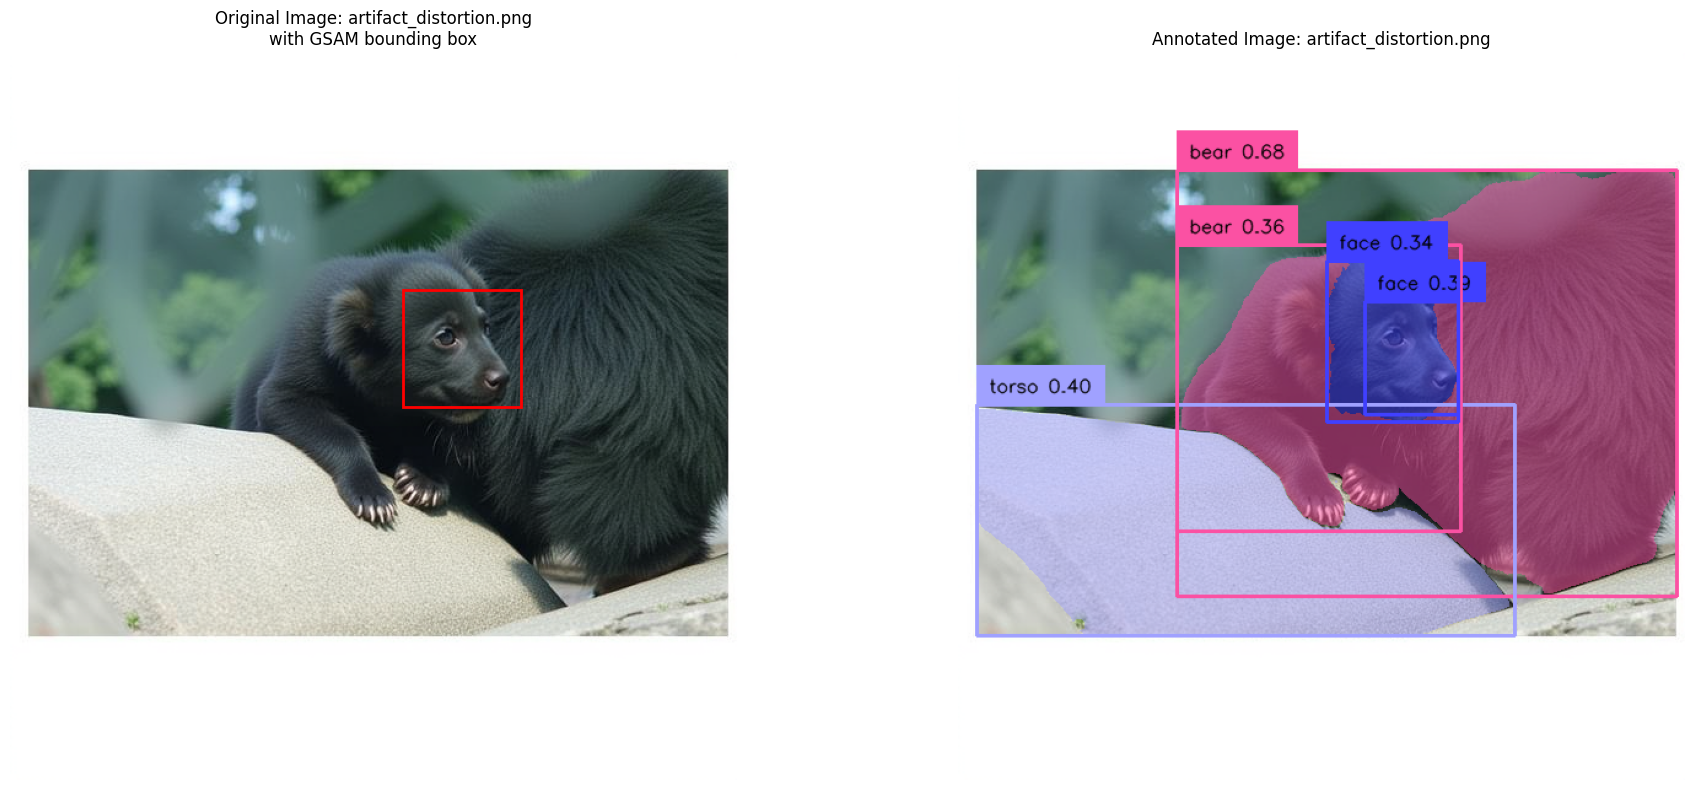

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot original image with bounding box
axes[0].imshow(img)

# Create rectangle patch for bounding box
rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                        linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)

axes[0].set_title(f"Original Image: {flux_image_path.name}\nwith GSAM bounding box")
axes[0].axis('off')

# Plot annotated image
axes[1].imshow(annotated_image.convert('RGB'))
axes[1].set_title(f"Annotated Image: {flux_image_path.name}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
def simple_check_prediction_covers_bbox(gsam_metadata, artifact_type, predictions, 
                                       confidence_threshold=0.3, coverage_threshold=0.4):
    """
    Simplified version: Just returns True/False if a prediction covers the target bbox.
    
    Args:
        gsam_metadata: The loaded GSAM metadata dictionary
        artifact_type: The specific artifact type key
        predictions: The predictions dictionary from GSAM detector
        confidence_threshold: Minimum confidence score (default: 0.3)
        coverage_threshold: Minimum coverage ratio of target bbox (default: 0.4 = 40%)
    
    Returns:
        bool: True if prediction with target class covers >40% of target bbox, False otherwise
    """    
    # Get target class name and find its index in vocab
    target_class_name = gsam_metadata['artifacts'][artifact_type]['class_name']
    vocab = gsam_metadata['vocab']
    target_class_idx = vocab.index(target_class_name)
    
    # Get target bbox
    target_bbox = gsam_metadata['artifacts'][artifact_type]['patch_data']['target_bbox']
    target_xmin, target_ymin, target_xmax, target_ymax = target_bbox
    
    # Check predictions
    for i, class_idx in enumerate(predictions['pred_classes']):
        if (class_idx.item() == target_class_idx and 
            predictions['scores'][i].item() >= confidence_threshold):
            
            # Get the prediction mask
            pred_mask = predictions['pred_masks'][i]
            
            # Create target bbox mask
            mask_height, mask_width = pred_mask.shape
            target_mask = torch.zeros((mask_height, mask_width), dtype=torch.bool)
            
            # Convert bbox coordinates to integer pixel coordinates
            bbox_xmin = max(0, int(target_xmin))
            bbox_ymin = max(0, int(target_ymin))
            bbox_xmax = min(mask_width, int(target_xmax))
            bbox_ymax = min(mask_height, int(target_ymax))
            
            # Fill target bbox area in mask
            target_mask[bbox_ymin:bbox_ymax, bbox_xmin:bbox_xmax] = True
            
            # Calculate intersection and coverage ratio
            intersection_area = torch.sum(pred_mask & target_mask).item()
            target_bbox_area = torch.sum(target_mask).item()
            coverage_ratio = intersection_area / target_bbox_area if target_bbox_area > 0 else 0
            
            if coverage_ratio >= coverage_threshold:
                return True
    
    return False

# Example usage:
# covers_bbox = simple_check_prediction_covers_bbox(gsam_metadata, artifact_type, predictions)
# print(f"Prediction covers >40% of target bbox: {covers_bbox}")


In [19]:
# Test the simplified function
if 'gsam_metadata' in locals() and 'artifact_type' in locals() and 'predictions' in locals():
    # Test with default thresholds
    covers_bbox = simple_check_prediction_covers_bbox(gsam_metadata, artifact_type, predictions)
    print(f"Simple check - Prediction covers >40% of target bbox: {covers_bbox}")
    
    # Test with different thresholds
    covers_bbox_20 = simple_check_prediction_covers_bbox(
        gsam_metadata, artifact_type, predictions, 
        confidence_threshold=0.3, coverage_threshold=0.2
    )
    print(f"Simple check - Prediction covers >20% of target bbox: {covers_bbox_20}")
    
    covers_bbox_60 = simple_check_prediction_covers_bbox(
        gsam_metadata, artifact_type, predictions, 
        confidence_threshold=0.3, coverage_threshold=0.6
    )
    print(f"Simple check - Prediction covers >60% of target bbox: {covers_bbox_60}")
    
else:
    print("Required variables not found. Please run previous cells first.")


Simple check - Prediction covers >40% of target bbox: True
Simple check - Prediction covers >20% of target bbox: True
Simple check - Prediction covers >60% of target bbox: True


In [ ]:
# Check if NO predictions overlap with target bbox (simple version)
no_overlap = check_no_prediction_overlaps_bbox(gsam_metadata, artifact_type, predictions)
print(f"No predictions overlap with target bbox: {no_overlap}")

no_overlap_5 = check_no_prediction_overlaps_bbox(
    gsam_metadata, artifact_type, predictions, 
    overlap_threshold=0.05  # 5% overlap threshold
)
no_overlap_20 = check_no_prediction_overlaps_bbox(
    gsam_metadata, artifact_type, predictions, 
    overlap_threshold=0.2   # 20% overlap threshold
)

print(f"No overlap (5% threshold): {no_overlap_5}")
print(f"No overlap (20% threshold): {no_overlap_20}")

# Function comparison summary:
print("Function Comparison:")
print("1. check_no_prediction_overlaps_bbox() - Returns True if NO predictions overlap with bbox")
print("2. simple_check_prediction_covers_bbox() - Returns True if predictions COVER the bbox")
print("3. These are opposite functions - one checks for absence of overlap, other checks for presence of coverage")

No predictions overlap with target bbox: False
No overlap (5% threshold): False
No overlap (20% threshold): False
Function Comparison:
1. check_no_prediction_overlaps_bbox() - Returns True if NO predictions overlap with bbox
2. simple_check_prediction_covers_bbox() - Returns True if predictions COVER the bbox
3. These are opposite functions - one checks for absence of overlap, other checks for presence of coverage
